# Sharpe ratio vs annualized Sharpe ratio

- The annualized Sharpe ratio is larger than the annual Sharpe ratio
- The difference increases with autocorrelation
- The difference increases with the (true) Sharpe ratio (the relation is reversed if the Sharpe ratio is very low, because the Sharpe ratio is computed from ratio returns)
- The difference increases with Non-Gaussianity (slowly)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from functions import generate_autocorrelated_non_gaussian_data

In [2]:
import ray
ray.init()

2026-01-06 07:18:20,501	INFO worker.py:1951 -- Started a local Ray instance.


Python version:,3.11.10
Ray version:,2.49.1


In [3]:
MODELS = ['gaussian', 'mild', 'moderate', 'severe']
RHOS = [0, .1, .2, .3, .4]
SR0S = [-.05, 0, .05, .1, .15, .2, .25]
SR0S = np.linspace( -.05, .25, 31 )
T = 20 * 252
N = 1_000

In [4]:
@ray.remote
def f(name, rho, SR0, T):
    np.random.seed(1)
    X_daily = generate_autocorrelated_non_gaussian_data(T, N, rho = rho, SR0 = SR0, name = name)
    X_daily = np.log1p( X_daily )
    years = T // 252
    X_annual = X_daily[:years*252].reshape(years, 252, X_daily.shape[1]).sum(axis=1)
    X_annual = np.expm1( X_annual )
    X_daily = np.expm1( X_daily )
    row = pd.DataFrame( { 
        'daily_annualized': X_daily.mean(axis=0) / X_daily.std(axis=0) * np.sqrt(252),
        'annual': X_annual.mean(axis=0) / X_annual.std(axis=0),
    } ).mean().round(2)
    row['rho'] = rho
    row['name'] = name
    row['SR0'] = SR0
    row['difference'] = row['daily_annualized'] - row['annual']
    return row

r = [
    f.remote(name, rho, SR0, T)
    for name in MODELS
    for rho in RHOS
    for SR0 in SR0S
]
r = [ ray.get(u) for u in tqdm(r) ]
r = pd.DataFrame( r )
r = r[['name', 'rho', 'SR0', 'daily_annualized', 'annual', 'difference']]

  0%|          | 0/620 [00:00<?, ?it/s]

In [5]:
for column in ['SR0', 'rho', 'name']:
    display( r.groupby(column)['difference'].mean().round(2) )

SR0
-0.05   -0.06
-0.04   -0.06
-0.03   -0.05
-0.02   -0.03
-0.01   -0.02
 0.00    0.01
 0.01    0.04
 0.02    0.07
 0.03    0.10
 0.04    0.14
 0.05    0.18
 0.06    0.23
 0.07    0.28
 0.08    0.33
 0.09    0.39
 0.10    0.44
 0.11    0.50
 0.12    0.57
 0.13    0.64
 0.14    0.71
 0.15    0.78
 0.16    0.86
 0.17    0.93
 0.18    1.01
 0.19    1.09
 0.20    1.18
 0.21    1.27
 0.22    1.36
 0.23    1.45
 0.24    1.54
 0.25    1.63
Name: difference, dtype: float64

rho
0.0    0.35
0.1    0.46
0.2    0.57
0.3    0.67
0.4    0.77
Name: difference, dtype: float64

name
gaussian    0.53
mild        0.56
moderate    0.57
severe      0.59
Name: difference, dtype: float64

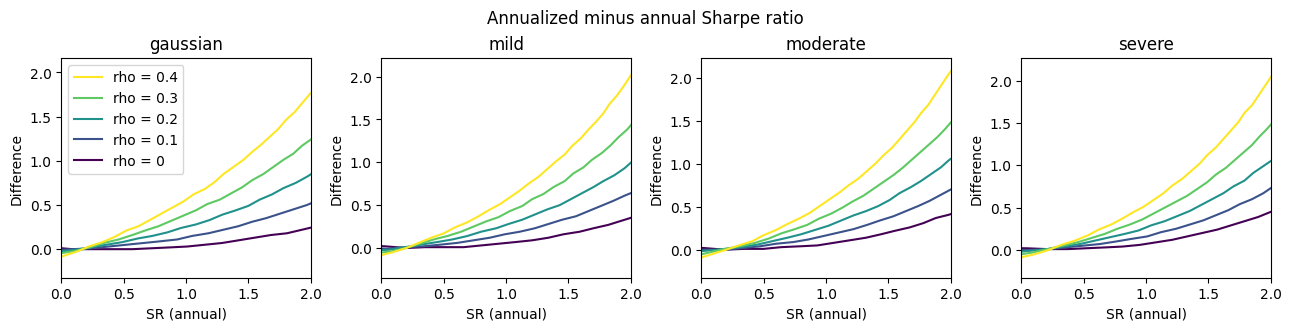

In [6]:
s = .8
fig, axs = plt.subplots(1, 4, figsize = (s*16,s*4), layout = 'constrained' )
colours = plt.cm.viridis( np.linspace(0, 1, len(RHOS)) )
for ax, name in zip(axs, MODELS):
    for rho, colour in zip(RHOS, colours):
        i1 = r['rho'] == rho
        i2 = r['name'] == name
        ax.plot( r['annual'][i1 & i2], r['difference'][i1 & i2], label = f'rho = {rho}', color = colour )
        #ax.plot( r['daily_annualized'][i1 & i2], r['difference'][i1 & i2], label = f'rho = {rho}', color = colour )
    if ax == axs[0]:
        ax.legend(reverse = True)
    ax.set_title(name)
    ax.set_xlabel('SR (annual)')
    ax.set_ylabel('Difference')
    ax.set_xlim( 0, 2 )
fig.suptitle('Annualized minus annual Sharpe ratio')
plt.show()

# Expected value of the maximum Sharpe ratio

In [7]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from functions import expected_maximum_sharpe_ratio, moments_Mk


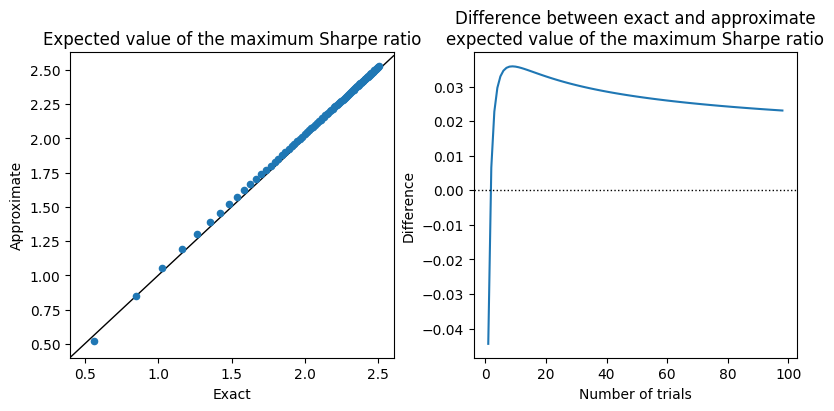

In [8]:
ks = np.arange(1, 100)
r = pd.DataFrame( { 
    'k': ks,
    'exact': [ moments_Mk(k)[0] for k in ks ],
    'approx': [ expected_maximum_sharpe_ratio(k, 1, 0) for k in ks ],
} )

fig, axs = plt.subplots(1, 2, figsize = (8,4), layout = 'constrained', dpi = 100 )

ax = axs[0]
r.plot.scatter(x='exact', y='approx', ax = ax)
ax.axline( (.5,.5), slope = 1, color = 'black', linewidth = 1, zorder = -2 )
ax.set_xlabel('Exact')
ax.set_ylabel('Approximate')
ax.set_title('Expected value of the maximum Sharpe ratio')

ax = axs[1]
( r['approx'] - r['exact'] ).plot(ax = ax)
ax.axhline(0, color = 'black', linewidth = 1, linestyle = ':' )
ax.set_xlabel('Number of trials')
ax.set_ylabel('Difference')
ax.set_title('Difference between exact and approximate\nexpected value of the maximum Sharpe ratio')

plt.show()

# Variance of the maximum Sharpe ratio

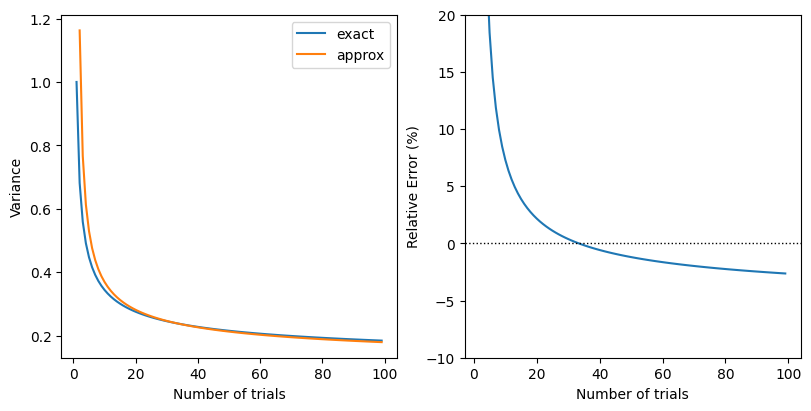

In [54]:
import scipy

def Z_inv(u): 
    return scipy.stats.norm.ppf(u)

def variance_1(k): 
    gamma = np.euler_gamma
    return ( 
        math.pi**2 / 6 - gamma**2 / ( 1 + gamma ) 
    ) * ( 
        Z_inv( 1 - 1/(k*np.exp(1)) ) -
        Z_inv( 1 - 1/k )
    ) ** 2

def variance_0(k): 
    gamma = np.euler_gamma
    return ( 
        math.pi**2 / 6 
    ) * ( 
        Z_inv( 1 - 1/(k*np.exp(1)) ) -
        Z_inv( 1 - 1/k )
    ) ** 2

def variance_2(k):  # ChatGPT -- valid for k VERY large
    a = Z_inv(1-1/k)
    return math.pi**2/6 / a**2

def variance_3(k):
    return math.pi**2/6 / np.log(k)


ks = np.arange(1, 100)
r = pd.DataFrame( { 
    'k': ks,
    'exact': [ moments_Mk(k)[2] for k in ks ],
    'approx': [ 
        variance_1(k)
        for k in ks 
    ],
} )

fig, axs = plt.subplots(1, 2, figsize = (8,4), layout = 'constrained', dpi = 100 )
ax = axs[0]
r.set_index('k').plot(ax = ax)
ax.set_xlabel('Number of trials')
ax.set_ylabel('Variance')

ax = axs[1]
ax.plot( r['k'], 100 * ( r['approx'] - r['exact'] ) / r['exact'] )
ax.set_xlabel('Number of trials')
ax.set_ylabel('Relative Error (%)')
ax.set_ylim( -10, 20 )
ax.axhline( 0, color = 'black', linewidth = 1, linestyle = ':' )
plt.show()

In [92]:
Phi = scipy.stats.norm.cdf
Phi_inv = scipy.stats.norm.ppf
phi = scipy.stats.norm.pdf
gamma = np.euler_gamma
e = np.exp(1)

k = 1000
a = Phi_inv(1-1/k)
b = Phi_inv(1-1/(k*np.exp(1))) - a

1/k * (1-1/k) / phi(a) * ( 1/phi(a+b) - 1/phi(a) ) / k
#gamma**2/(1+gamma)


(k-1)/k**3 / phi(a) * ( 1/phi(a)/e - 1/phi(a+b) )

#gamma**2 / (1+gamma)


np.float64(-0.1894832111857174)

In [ ]:
k = 1000
N = 10_000
R = 10_000
x = np.random.normal( size = (N,R) )
a = np.quantile( x, 1-1/k, axis=1 )
b = np.quantile( x, 1-1/(k*np.exp(1)), axis=1 ) - a
np.cov( np.vstack([a,b]) )[0,1], -1/np.log(k)**2/4


(np.float64(-0.00044619516956858317), np.float64(-0.005239213805878165))

array([  10,   20,   41,   85,  175,  359,  735, 1505, 3082, 6309])

In [149]:
tmp = []
for k in np.logspace(1,5,20).astype(int):
    print( k )
    N = 10_000
    R = k*5
    x = np.random.normal( size = (N,R) )
    a = np.quantile( x, 1-1/k, axis=1 )
    b = np.quantile( x, 1-1/(k*np.exp(1)), axis=1 ) - a
    tmp.append( { 
        'k': k,
        'cov': np.cov( np.vstack([a,b]) )[0,1],
        'expected': -1/np.log(k)**2/4 * k/R,
    })
tmp = pd.DataFrame( tmp )

10
16
26
42
69
112
183
297
483
784
1274
2069
3359
5455
8858
14384
23357
37926
61584
100000


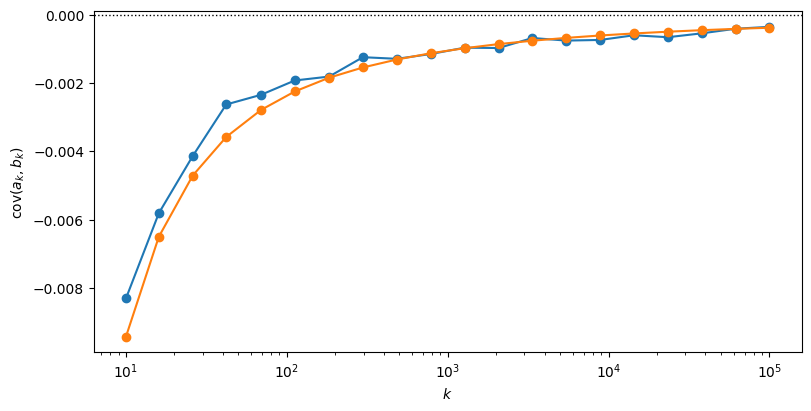

In [ ]:
tmp = pd.DataFrame( tmp )
fig, ax = plt.subplots( figsize = (8,4), layout = 'constrained' )
ax.plot( tmp.set_index('k'), marker = 'o' )
#ax.plot( tmp['k'], -1/np.log(tmp['k'])**2/16, linestyle = ':' )
ax.axhline( 0, linewidth = 1, linestyle = ':', color = 'black' )
#ax.axhline( -gamma**2/(1+gamma), linewidth = 1, linestyle = ':', color = 'black' )
#ax.set_ylim( -0.001, .001 )
ax.set_xscale('log')
ax.set_ylabel(r"$\text{cov}(a_k,b_k)$")
ax.set_xlabel(r"$k$")
plt.show()

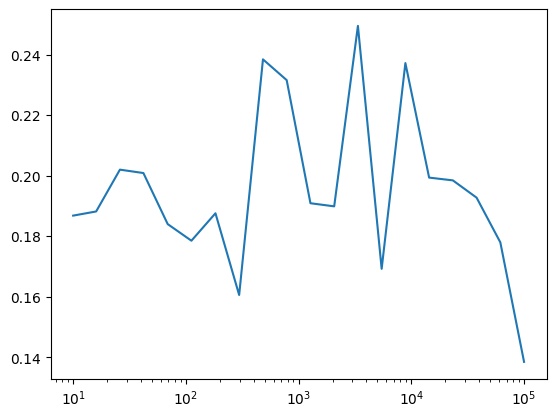

In [145]:
plt.plot( tmp['k'], - tmp['cov'] * np.log(tmp['k'])**2 * 4 )
plt.xscale('log')

In [148]:
gamma**2 / (1+gamma)

0.21124436639964472

In [ ]:
k = 1000
phi( Phi_inv(1-1/k) ), np.sqrt(2*np.log(k))/k

(np.float64(0.003367090077063995), np.float64(0.0037169221888498382))